In [1]:
import os
import glob
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# Dataset path

DATASET_PATH = "/kaggle/input/datasets/jangedoo/utkface-new/UTKFace"

print(DATASET_PATH)

/kaggle/input/datasets/jangedoo/utkface-new/UTKFace


In [3]:
image_files = glob.glob(DATASET_PATH + "/*.jpg")

print("Number of images :", len(image_files))

Number of images : 23708


In [4]:
def extract_labels(filepath):
    
    filename = os.path.basename(filepath)
    
    parts = filename.split("_")
    
    age = int(parts[0])
    gender = int(parts[1])
    race = int(parts[2])
    
    return age, gender, race

In [5]:
data = []

for img_path in image_files:
    
    try:
        age, gender, race = extract_labels(img_path)
        
        data.append(
            {
                "image_path": img_path,
                "age": age,
                "gender": gender,
                "race": race
            }
        )
        
    except:
        pass


df = pd.DataFrame(data)

df.head()

,image_path,age,gender,race
0,/kaggle/input/datasets/jangedoo/utkface-new/UT...,26,0,2
1,/kaggle/input/datasets/jangedoo/utkface-new/UT...,22,1,1
2,/kaggle/input/datasets/jangedoo/utkface-new/UT...,21,1,3
3,/kaggle/input/datasets/jangedoo/utkface-new/UT...,28,0,0
4,/kaggle/input/datasets/jangedoo/utkface-new/UT...,17,1,4


In [6]:
print("Total images:", len(df))

Total images: 23705


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23705 entries, 0 to 23704
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_path  23705 non-null  object
 1   age         23705 non-null  int64 
 2   gender      23705 non-null  int64 
 3   race        23705 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 740.9+ KB


In [8]:
df.describe()

,age,gender,race
count,23705.000000,23705.000000,23705.000000
mean,33.300907,0.477283,1.269226
std,19.885708,0.499494,1.345638
min,1.000000,0.000000,0.000000
25%,23.000000,0.000000,0.000000
50%,29.000000,0.000000,1.000000
75%,45.000000,1.000000,2.000000
max,116.000000,1.000000,4.000000


In [9]:
df["age"].min(), df["age"].max()

(1, 116)

In [10]:
df["gender"].value_counts()

gender
0    12391
1    11314
Name: count, dtype: int64

In [11]:
df["race"].value_counts()

race
0    10078
1     4526
3     3975
2     3434
4     1692
Name: count, dtype: int64

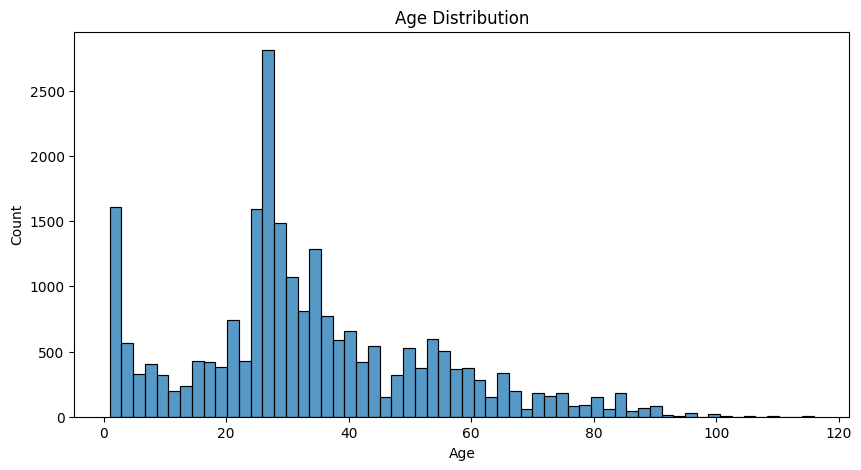

In [12]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["age"],
    bins=60
)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.show()

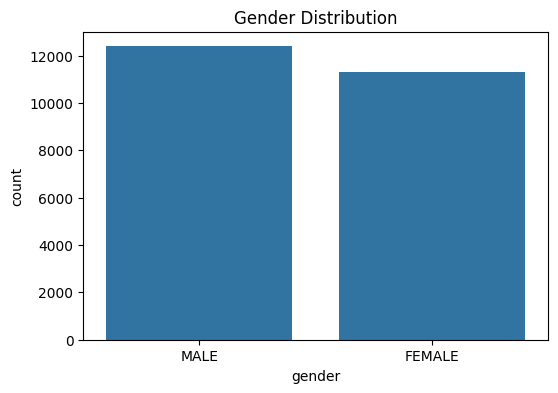

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="gender",
    data=df
)

plt.title("Gender Distribution")
plt.xticks(ticks=[0, 1], labels=["MALE","FEMALE"])
plt.show()

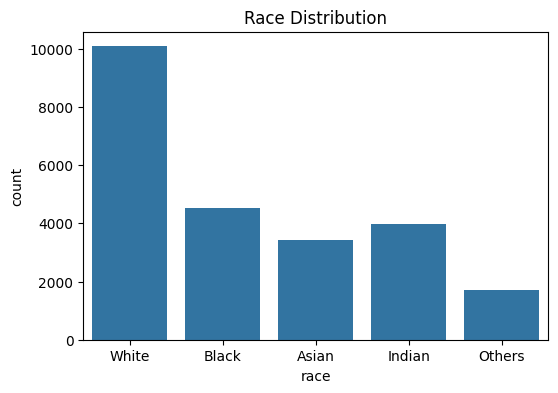

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="race",
    data=df
)

plt.title("Race Distribution")
plt.xticks(ticks=[0, 1, 2, 3, 4], labels=["White", "Black", "Asian", "Indian", "Others"])
plt.show()

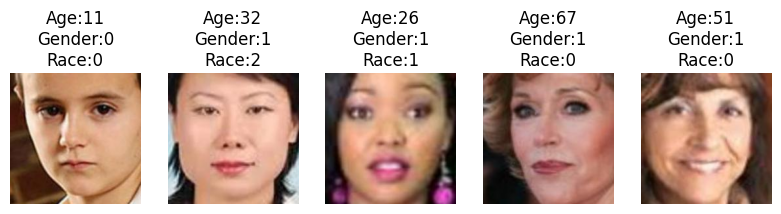

In [15]:
def show_images(dataframe, n=5):

    sample = dataframe.sample(n)

    plt.figure(figsize=(20,20))

    for i, row in enumerate(sample.itertuples()):

        img = Image.open(row.image_path)

        plt.subplot(10,10,i+1)

        plt.imshow(img)

        plt.title(
            f"Age:{row.age}\nGender:{row.gender}\nRace:{row.race}"
        )

        plt.axis("off")
        
show_images(df)

In [16]:
df.to_csv(
    "/kaggle/working/utkface_metadata.csv",
    index=False
)

print("Metadata saved")

Metadata saved


In [17]:
df_preview = pd.read_csv("/kaggle/working/utkface_metadata.csv", nrows=10)
print(df_preview)

                                          image_path  age  gender  race
0  /kaggle/input/datasets/jangedoo/utkface-new/UT...   26       0     2
1  /kaggle/input/datasets/jangedoo/utkface-new/UT...   22       1     1
2  /kaggle/input/datasets/jangedoo/utkface-new/UT...   21       1     3
3  /kaggle/input/datasets/jangedoo/utkface-new/UT...   28       0     0
4  /kaggle/input/datasets/jangedoo/utkface-new/UT...   17       1     4
5  /kaggle/input/datasets/jangedoo/utkface-new/UT...   44       0     3
6  /kaggle/input/datasets/jangedoo/utkface-new/UT...   35       0     2
7  /kaggle/input/datasets/jangedoo/utkface-new/UT...   76       0     0
8  /kaggle/input/datasets/jangedoo/utkface-new/UT...   36       1     0
9  /kaggle/input/datasets/jangedoo/utkface-new/UT...   34       0     3
